In [6]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
# Load ground data
ground_folder_addr = "./all_merged_data/"
ground_csv_filenames = [f"Station{i}_AMSR_SMAP_Merged.csv" for i in range(1, 7)]

merged_sm_data = []
for filename in ground_csv_filenames:
    df = pd.read_csv(ground_folder_addr + filename, parse_dates=['Date'])
    df.set_index('Date', inplace=True)
    merged_sm_data.append(df)

In [14]:
# Function to compare satellite data with ground measurements
def compare_satellite_data(df, satellite_column, distance_column, ground_column, max_distance=20):
    # Calculate overall differences
    overall_diff = df[satellite_column] - df[ground_column]
    
    # Calculate differences for measurements within max_distance
    close_measurements = df[df[distance_column] <= max_distance]
    close_diff = close_measurements[satellite_column] - close_measurements[ground_column]
    
    # Plot histograms
    plt.figure(figsize=(12, 6))
    plt.hist(overall_diff, bins=50, alpha=0.5, label='All measurements')
    plt.hist(close_diff, bins=50, alpha=0.5, label=f'Within {max_distance} miles')
    plt.xlabel('Difference (Satellite - Ground)')
    plt.ylabel('Frequency')
    plt.title(f'Difference between {satellite_column} and {ground_column}')
    plt.legend()
    plt.show()
    
    # Print statistics
    print(f"Overall mean difference: {overall_diff.mean():.4f}")
    print(f"Overall median difference: {overall_diff.median():.4f}")
    print(f"Overall standard deviation: {overall_diff.std():.4f}")
    print(f"\nMean difference within {max_distance} miles: {close_diff.mean():.4f}")
    print(f"Median difference within {max_distance} miles: {close_diff.median():.4f}")
    print(f"Standard deviation within {max_distance} miles: {close_diff.std():.4f}")



Station 1
AMSR vs SWC_5:


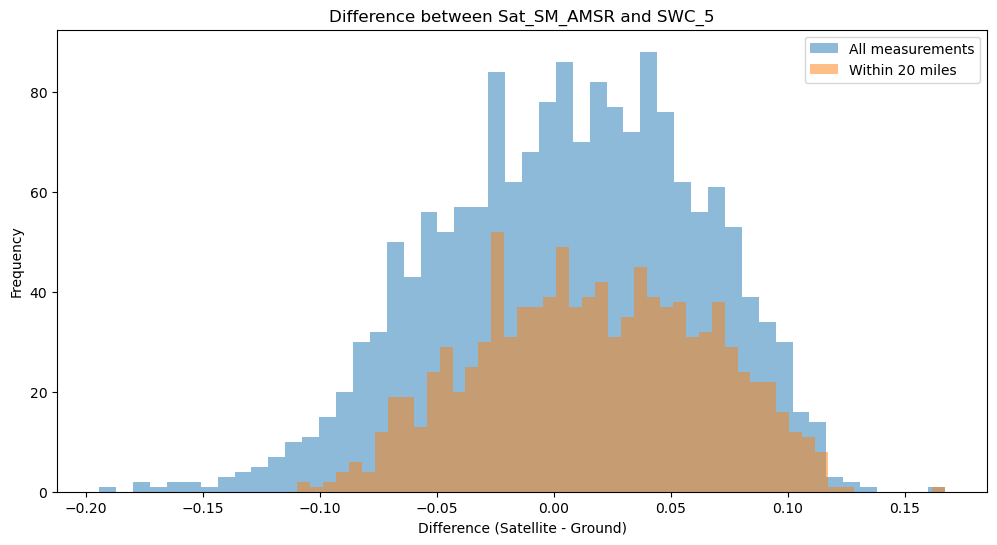

Overall mean difference: 0.0055
Overall median difference: 0.0079
Overall standard deviation: 0.0554

Mean difference within 20 miles: 0.0166
Median difference within 20 miles: 0.0162
Standard deviation within 20 miles: 0.0489

SMAP vs SWC_5:


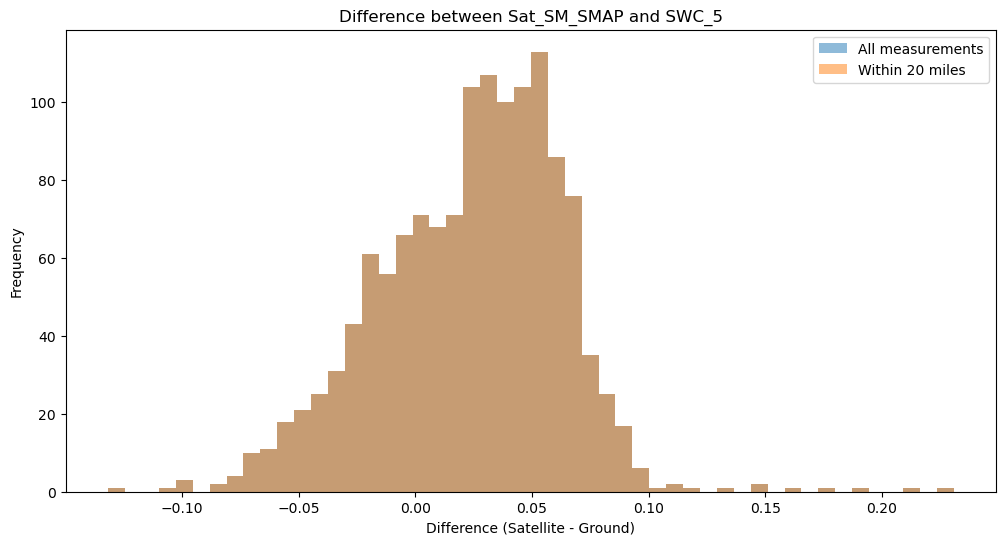

Overall mean difference: 0.0235
Overall median difference: 0.0282
Overall standard deviation: 0.0394

Mean difference within 20 miles: 0.0235
Median difference within 20 miles: 0.0282
Standard deviation within 20 miles: 0.0394



Station 2
AMSR vs SWC_5:


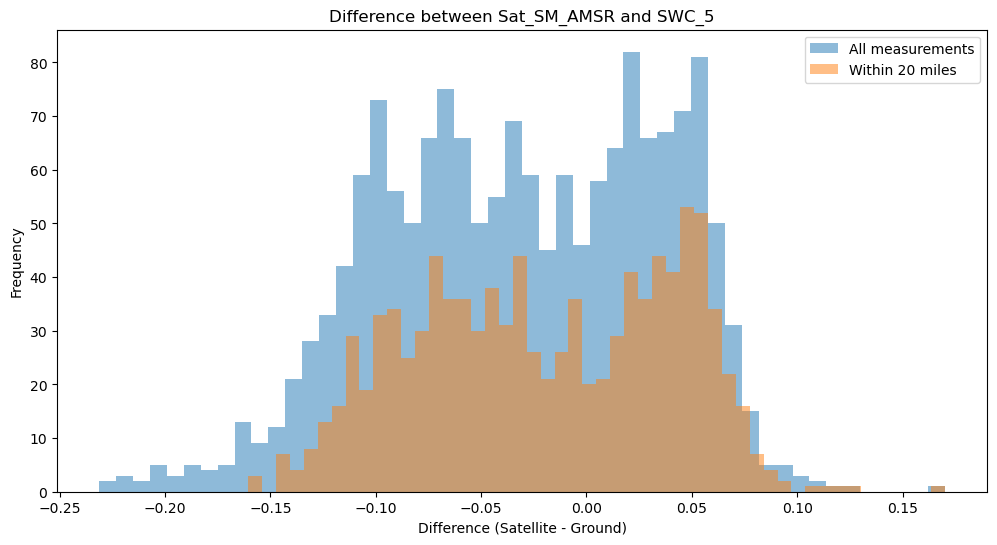

Overall mean difference: -0.0310
Overall median difference: -0.0302
Overall standard deviation: 0.0659

Mean difference within 20 miles: -0.0196
Median difference within 20 miles: -0.0209
Standard deviation within 20 miles: 0.0603

SMAP vs SWC_5:


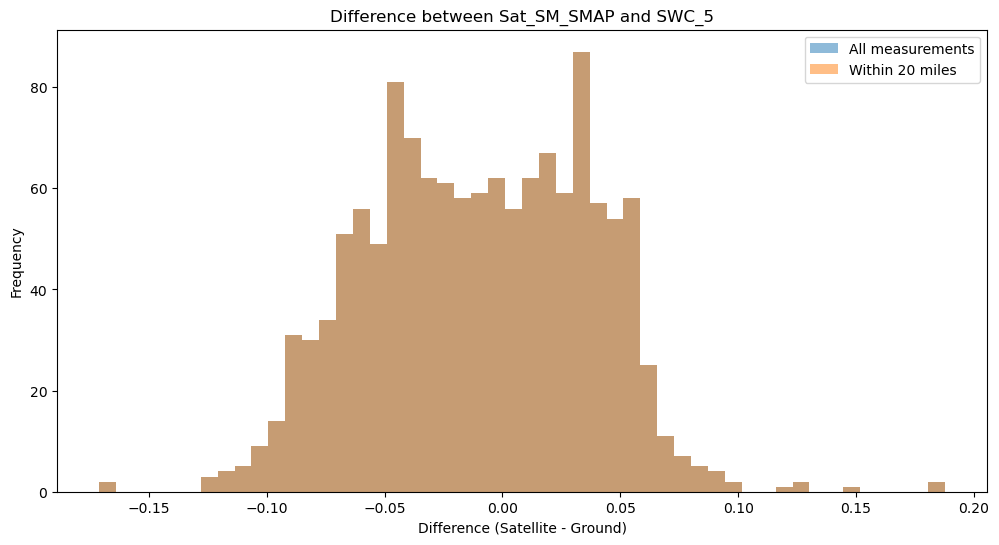

Overall mean difference: -0.0100
Overall median difference: -0.0086
Overall standard deviation: 0.0470

Mean difference within 20 miles: -0.0100
Median difference within 20 miles: -0.0086
Standard deviation within 20 miles: 0.0470



Station 3
AMSR vs SWC_5:


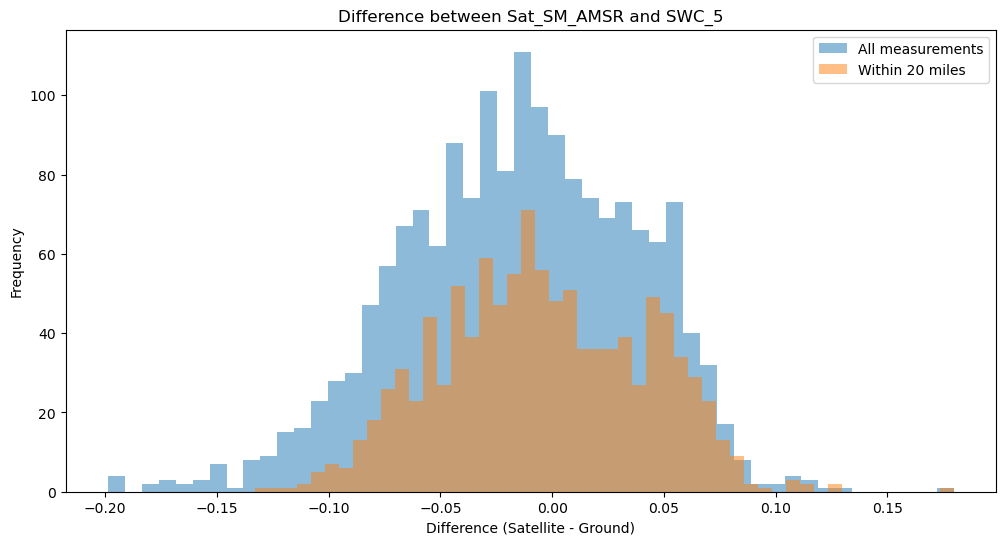

Overall mean difference: -0.0152
Overall median difference: -0.0131
Overall standard deviation: 0.0523

Mean difference within 20 miles: -0.0042
Median difference within 20 miles: -0.0069
Standard deviation within 20 miles: 0.0456

SMAP vs SWC_5:


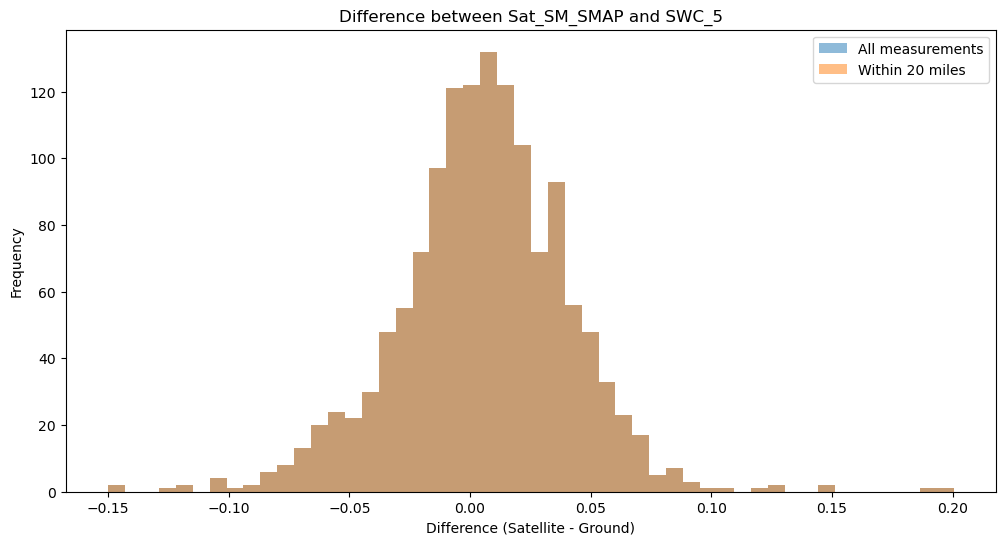

Overall mean difference: 0.0054
Overall median difference: 0.0061
Overall standard deviation: 0.0355

Mean difference within 20 miles: 0.0054
Median difference within 20 miles: 0.0061
Standard deviation within 20 miles: 0.0355



Station 4
AMSR vs SWC_5:


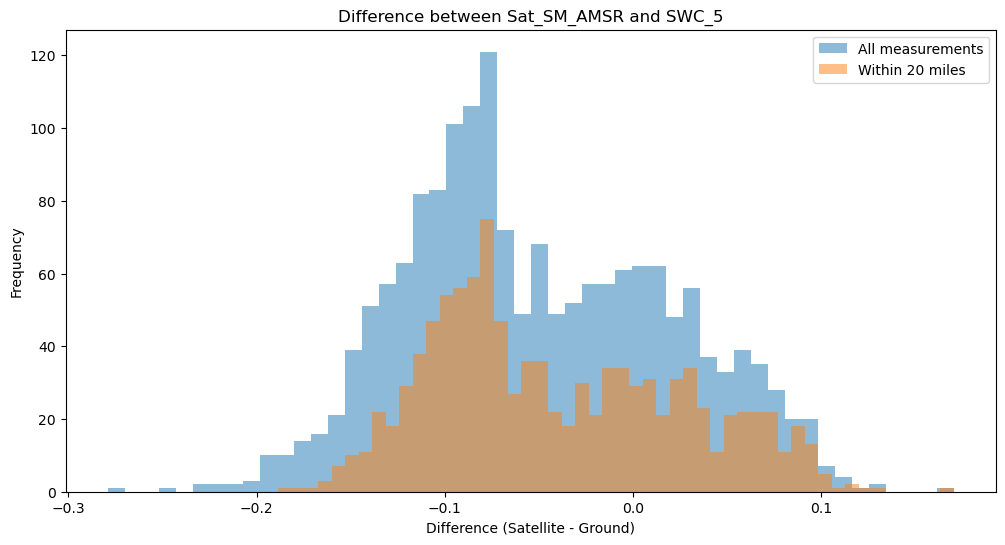

Overall mean difference: -0.0508
Overall median difference: -0.0639
Overall standard deviation: 0.0701

Mean difference within 20 miles: -0.0403
Median difference within 20 miles: -0.0555
Standard deviation within 20 miles: 0.0664

SMAP vs SWC_5:


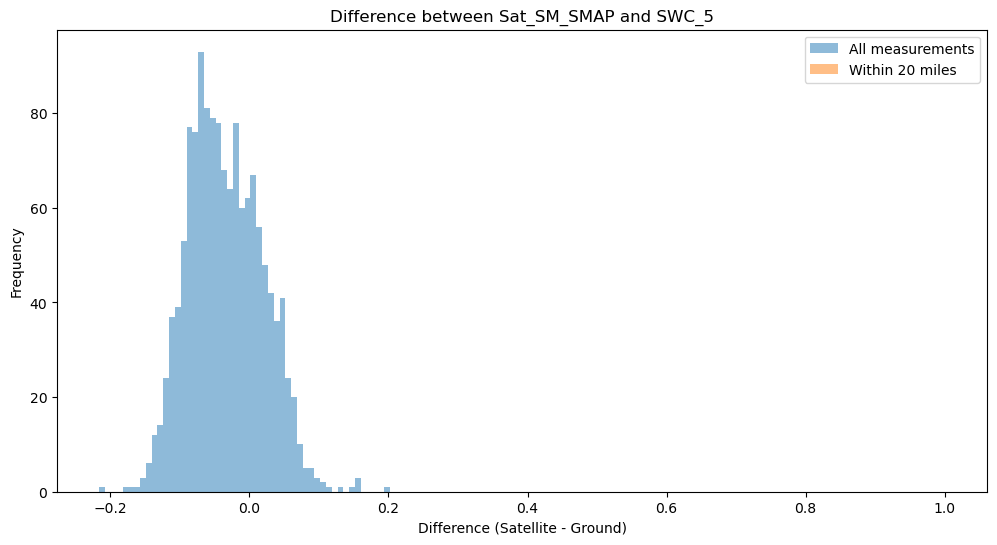

Overall mean difference: -0.0342
Overall median difference: -0.0389
Overall standard deviation: 0.0534

Mean difference within 20 miles: nan
Median difference within 20 miles: nan
Standard deviation within 20 miles: nan



Station 5
AMSR vs SWC_5:


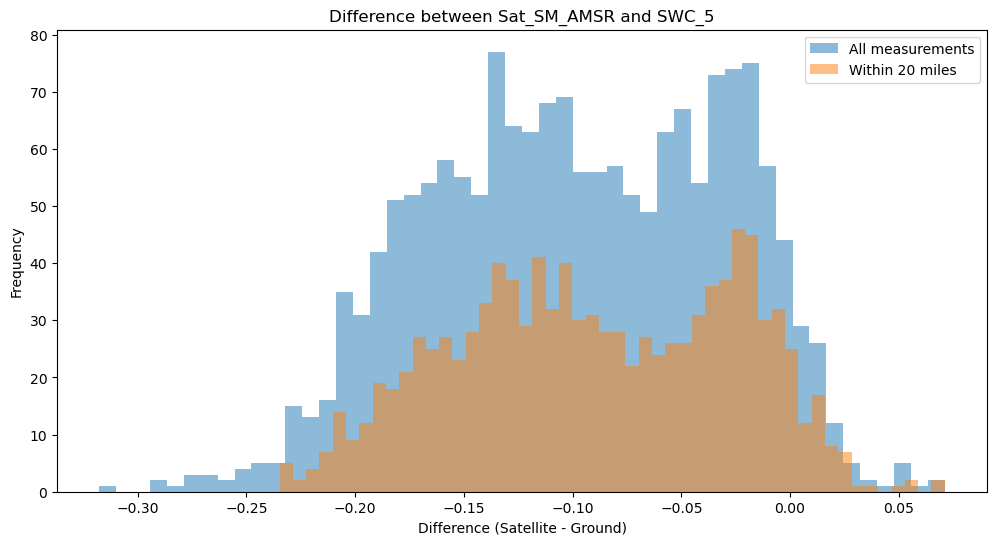

Overall mean difference: -0.0980
Overall median difference: -0.0976
Overall standard deviation: 0.0670

Mean difference within 20 miles: -0.0896
Median difference within 20 miles: -0.0921
Standard deviation within 20 miles: 0.0632

SMAP vs SWC_5:


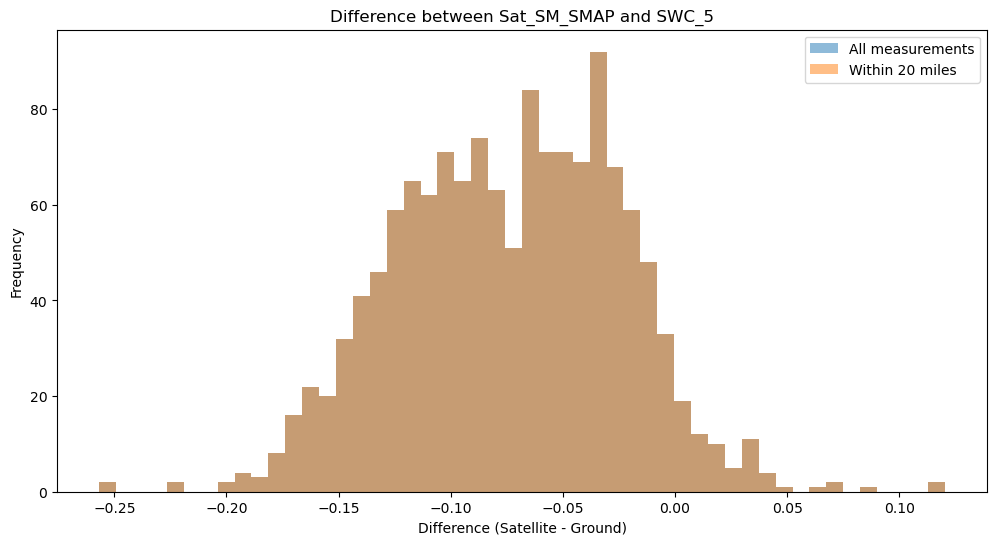

Overall mean difference: -0.0739
Overall median difference: -0.0721
Overall standard deviation: 0.0496

Mean difference within 20 miles: -0.0739
Median difference within 20 miles: -0.0721
Standard deviation within 20 miles: 0.0496



Station 6
AMSR vs SWC_5:


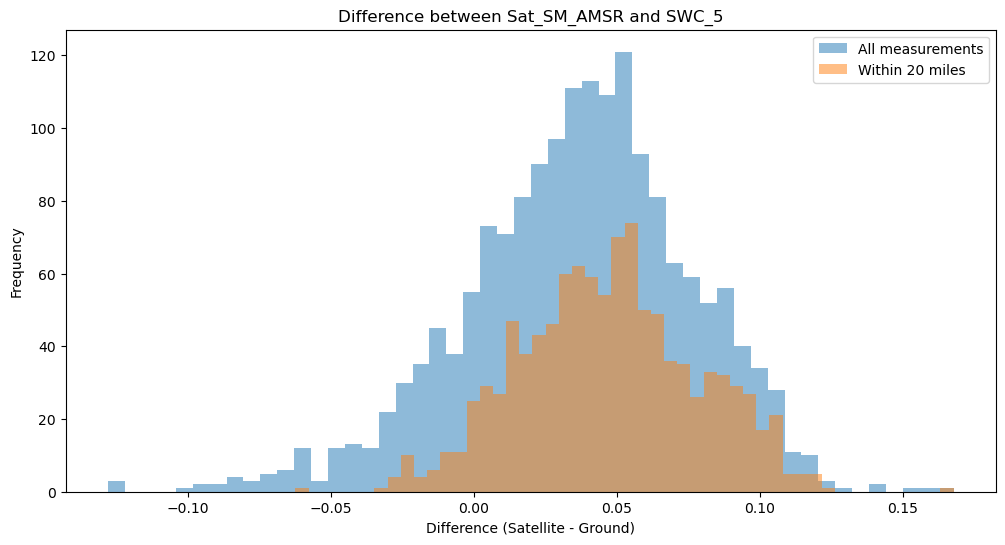

Overall mean difference: 0.0365
Overall median difference: 0.0390
Overall standard deviation: 0.0398

Mean difference within 20 miles: 0.0473
Median difference within 20 miles: 0.0469
Standard deviation within 20 miles: 0.0310

SMAP vs SWC_5:


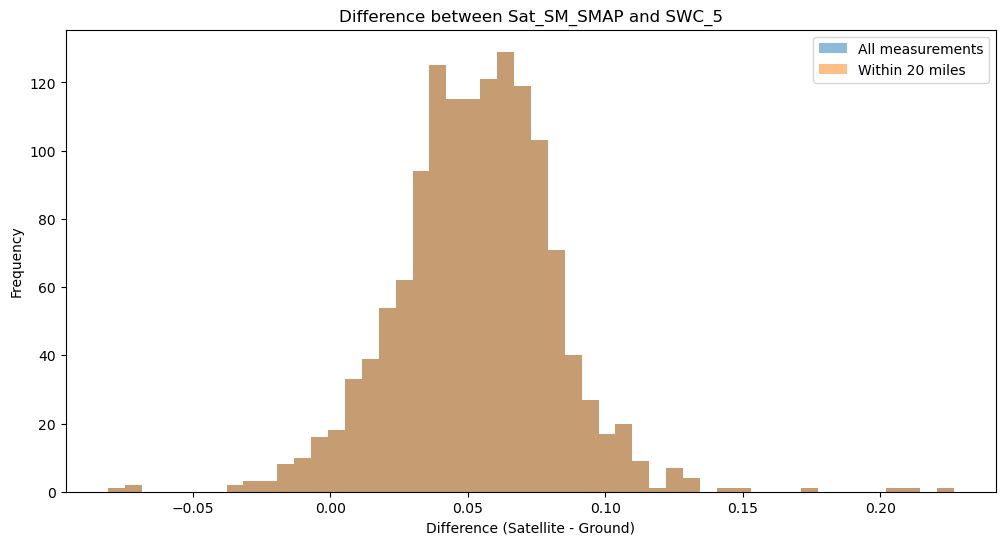

Overall mean difference: 0.0530
Overall median difference: 0.0539
Overall standard deviation: 0.0287

Mean difference within 20 miles: 0.0530
Median difference within 20 miles: 0.0539
Standard deviation within 20 miles: 0.0287




In [15]:
# Analyze each station
for i, df in enumerate(merged_sm_data):
    print(f"\nStation {i+1}")
    print("AMSR vs SWC_5:")
    compare_satellite_data(df, 'Sat_SM_AMSR', 'distance_AMSR', 'SWC_5')
    print("\nSMAP vs SWC_5:")
    compare_satellite_data(df, 'Sat_SM_SMAP', 'distance_SMAP', 'SWC_5')
    print("\n" + "="*50 + "\n")

In [18]:
import pandas as pd
import numpy as np
import os

# Create 'satellite' directory if it doesn't exist
os.makedirs('satellite', exist_ok=True)

# Load ground data
ground_folder_addr = "./all_merged_data/"
ground_csv_filenames = [f"Station{i}_AMSR_SMAP_Merged.csv" for i in range(1, 7)]

merged_sm_data = []
for filename in ground_csv_filenames:
    df = pd.read_csv(ground_folder_addr + filename, parse_dates=['Date'])
    df.set_index('Date', inplace=True)
    merged_sm_data.append(df)

def compare_satellite_data(df, satellite_column, distance_column, ground_column):
    results = []
    for max_distance in range(5, 205, 5):
        close_measurements = df[df[distance_column] <= max_distance]
        close_diff = close_measurements[satellite_column] - close_measurements[ground_column]
        
        results.append({
            'Max Distance': max_distance,
            'Mean Difference': close_diff.mean(),
            'Median Difference': close_diff.median(),
            'Standard Deviation': close_diff.std(),
            'Count': len(close_diff)
        })
    
    return pd.DataFrame(results)

# Open the output file
with open('satellite/distances.txt', 'w') as f:
    # Analyze each station
    for i, df in enumerate(merged_sm_data):
        f.write(f"Station {i+1}\n")
        f.write("AMSR vs SWC_5:\n")
        amsr_results = compare_satellite_data(df, 'Sat_SM_AMSR', 'distance_AMSR', 'SWC_5')
        f.write(amsr_results.to_string(index=False))
        min_std_amsr = amsr_results['Standard Deviation'].min()
        min_dist_amsr = amsr_results.loc[amsr_results['Standard Deviation'].idxmin(), 'Max Distance']
        f.write(f"\nLowest standard deviation for AMSR: {min_std_amsr:.4f} at {min_dist_amsr} miles\n")
        
        f.write("\nSMAP vs SWC_5:\n")
        smap_results = compare_satellite_data(df, 'Sat_SM_SMAP', 'distance_SMAP', 'SWC_5')
        f.write(smap_results.to_string(index=False))
        min_std_smap = smap_results['Standard Deviation'].min()
        min_dist_smap = smap_results.loc[smap_results['Standard Deviation'].idxmin(), 'Max Distance']
        f.write(f"\nLowest standard deviation for SMAP: {min_std_smap:.4f} at {min_dist_smap} miles\n")
        
        f.write("\n" + "="*50 + "\n\n")

print("Analysis complete. Results written to satellite/distances.txt")

Analysis complete. Results written to satellite/distances.txt
